### Problem Statement

Porter, India's leading intra-city logistics marketplace, partners with a large network of restaurants and delivery partners to provide timely food deliveries to millions of customers. A key factor influencing customer satisfaction is the accuracy of the estimated delivery time (ETA) displayed at the time of placing an order.

However, delivery time is influenced by several dynamic factors such as the restaurant location, delivery destination, traffic conditions, weather, order characteristics, and the availability of delivery partners. Providing inaccurate ETAs can lead to poor customer experience, increased support requests, and operational inefficiencies.

The objective of this project is to develop a Neural Network-based regression model that accurately predicts the food delivery time using historical order and delivery data. The model will learn complex, non-linear relationships among various features to generate reliable delivery time estimates, enabling Porter to improve customer satisfaction, optimize delivery operations, and enhance overall service quality.

### Objective

Develop a Neural Network-based regression model to accurately predict food delivery time for Porter using historical order, restaurant, and delivery partner data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Porter Neural Networks/data/data_2.csv")
df_copy = df.copy()
df.shape

(175777, 14)

#### Exploratory Data Analysis

In [3]:
df.columns

Index(['market_id', 'created_at', 'actual_delivery_time',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration'],
      dtype='object')

#### Columns Definitions:
- market_id : integer id for the market where the restaurant lies
- created_at : the timestamp at which the order was placed
- actual_delivery_time : the timestamp when the order was delivered
- store_primary_category : category for the restaurant
- order_protocol : integer code value for order protocol(how the order was placed ie: through porter, call to restaurant, pre booked, third part etc)
- total_items subtotal : final price of the order
- num_distinct_items : the number of distinct items in the order
- min_item_price : price of the cheapest item in the order
- max_item_price : price of the costliest item in order
- total_onshift_partners : number of delivery partners on duty at the time order was placed
- total_busy_partners : number of delivery partners attending to other tasks
- total_outstanding_orders : total number of orders to be fulfilled at the moment
- estimated_store_to_consumer_driving_duration : approximate travel time from restaurant to customer

In [4]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [5]:
# basic information of the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

In [6]:
# convert to datetime

cols = ['created_at', 'actual_delivery_time']
df[cols] = df[cols].apply(pd.to_datetime, errors='coerce')

In [7]:
df.dtypes

market_id                                              float64
created_at                                      datetime64[ns]
actual_delivery_time                            datetime64[ns]
store_primary_category                                   int64
order_protocol                                         float64
total_items                                              int64
subtotal                                                 int64
num_distinct_items                                       int64
min_item_price                                           int64
max_item_price                                           int64
total_onshift_dashers                                  float64
total_busy_dashers                                     float64
total_outstanding_orders                               float64
estimated_store_to_consumer_driving_duration           float64
dtype: object

In [8]:
# creating a target feature

df['est_delivery'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds()/60

In [9]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,est_delivery
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46.0


In [10]:
# checking the data types of the dataset

df.dtypes

market_id                                              float64
created_at                                      datetime64[ns]
actual_delivery_time                            datetime64[ns]
store_primary_category                                   int64
order_protocol                                         float64
total_items                                              int64
subtotal                                                 int64
num_distinct_items                                       int64
min_item_price                                           int64
max_item_price                                           int64
total_onshift_dashers                                  float64
total_busy_dashers                                     float64
total_outstanding_orders                               float64
estimated_store_to_consumer_driving_duration           float64
est_delivery                                           float64
dtype: object

In [11]:
# checking null values

df.isna().sum()

market_id                                       0
created_at                                      0
actual_delivery_time                            0
store_primary_category                          0
order_protocol                                  0
total_items                                     0
subtotal                                        0
num_distinct_items                              0
min_item_price                                  0
max_item_price                                  0
total_onshift_dashers                           0
total_busy_dashers                              0
total_outstanding_orders                        0
estimated_store_to_consumer_driving_duration    0
est_delivery                                    0
dtype: int64

In [12]:
# creating hour and day of week features

df['hour_of_day'] = df['created_at'].dt.hour

df['day_of_week'] = df['created_at'].dt.dayofweek

df.head(10)

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,est_delivery,hour_of_day,day_of_week
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47.0,22,4
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44.0,21,1
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55.0,0,0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59.0,3,3
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46.0,2,1
5,1.0,2015-02-06 00:42:42,2015-02-06 01:38:42,38,1.0,3,4475,3,925,1825,4.0,1.0,1.0,542.0,56.0,0,4
6,1.0,2015-02-08 02:04:17,2015-02-08 03:07:17,38,1.0,3,4375,3,1325,1625,6.0,4.0,3.0,789.0,63.0,2,6
7,1.0,2015-01-31 04:35:54,2015-01-31 05:33:54,38,1.0,2,3150,2,1425,1725,4.0,9.0,12.0,548.0,58.0,4,5
8,1.0,2015-01-31 02:21:23,2015-01-31 02:58:23,46,1.0,2,950,2,150,700,24.0,24.0,26.0,212.0,37.0,2,5
9,1.0,2015-01-31 23:45:12,2015-02-01 00:26:12,46,1.0,5,1285,3,150,400,12.0,13.0,11.0,424.0,41.0,23,5


In [13]:
df.dtypes

market_id                                              float64
created_at                                      datetime64[ns]
actual_delivery_time                            datetime64[ns]
store_primary_category                                   int64
order_protocol                                         float64
total_items                                              int64
subtotal                                                 int64
num_distinct_items                                       int64
min_item_price                                           int64
max_item_price                                           int64
total_onshift_dashers                                  float64
total_busy_dashers                                     float64
total_outstanding_orders                               float64
estimated_store_to_consumer_driving_duration           float64
est_delivery                                           float64
hour_of_day                                            

In [14]:
# checking categorical features

cat_cols = ['market_id', 'store_primary_category', 'order_protocol']

for col in cat_cols:
    print(df[col].value_counts())
    print("----------------------")

market_id
2.0    53469
4.0    46222
1.0    37115
3.0    21075
5.0    17258
6.0      638
Name: count, dtype: int64
----------------------
store_primary_category
4     18183
55    15745
46    15586
13     9915
58     8995
      ...  
1        10
43        9
8         2
21        1
3         1
Name: count, Length: 73, dtype: int64
----------------------
order_protocol
1.0    48404
3.0    47125
5.0    41415
2.0    20890
4.0    17246
6.0      678
7.0       19
Name: count, dtype: int64
----------------------


We can clearly see, there are certain store_primary_category with less observations, and One-hot encoding all 73 categories would create many columns that contribute very little and may increase model complexity. Instead, we can group the lower observation category as others.

In [15]:
value_counts = df['store_primary_category'].value_counts()

rare_categories = value_counts[value_counts < 100].index

df['store_primary_category'] = (df['store_primary_category'].replace(rare_categories, 'Other'))

In [16]:
df['store_primary_category'].value_counts()

store_primary_category
4        18183
55       15745
46       15586
13        9915
58        8995
20        8563
39        8232
24        8085
38        6733
28        6495
36        6378
68        6235
72        5570
45        5138
10        4841
50        3714
57        3468
34        2951
7         2672
59        2590
6         2219
66        2103
15        2027
2         1745
40        1693
18        1550
61        1525
47        1457
35        1451
65        1032
25         992
71         755
14         639
Other      638
52         625
53         574
30         557
42         490
12         428
23         330
16         310
9          293
49         287
29         259
17         243
70         232
54         230
69         220
31         182
51         139
11         125
67         125
26         110
0          103
Name: count, dtype: int64

In [17]:
# checking the unique categories after grouping

df['store_primary_category'].nunique()

54

In [18]:
# now, checking the variance between categories

df.groupby('market_id')['est_delivery'].mean().sort_values()

market_id
3.0    44.129015
2.0    44.875404
5.0    44.999710
4.0    46.776297
6.0    47.031348
1.0    49.124613
Name: est_delivery, dtype: float64

In [19]:
df.groupby('order_protocol')['est_delivery'].mean().sort_values()

order_protocol
7.0    41.947368
4.0    43.229155
5.0    44.777786
6.0    45.942478
3.0    46.646196
2.0    46.695979
1.0    47.843112
Name: est_delivery, dtype: float64

In [20]:
df.groupby('store_primary_category')['est_delivery'].mean().sort_values()

store_primary_category
23       41.903030
12       42.179907
28       42.678522
58       42.878488
15       43.289591
61       44.083934
49       44.160279
10       44.390415
46       44.552098
13       44.580131
2        44.924355
50       44.957997
72       45.294255
51       45.553957
35       45.564438
24       45.786271
34       45.826499
57       45.942042
4        45.967222
29       46.073359
6        46.094187
45       46.319190
47       46.538092
59       46.615058
69       46.922727
52       46.995200
71       47.127152
30       47.132855
20       47.283662
54       47.369565
53       47.402439
55       47.443887
42       47.522449
31       47.538462
25       47.599798
18       47.972903
36       48.057385
7        48.126871
40       48.165978
26       48.227273
11       48.480000
67       48.568000
68       48.583480
0        48.747573
70       48.982759
38       49.116441
39       49.146987
Other    49.214734
16       49.438710
65       49.467054
14       49.871674
17      

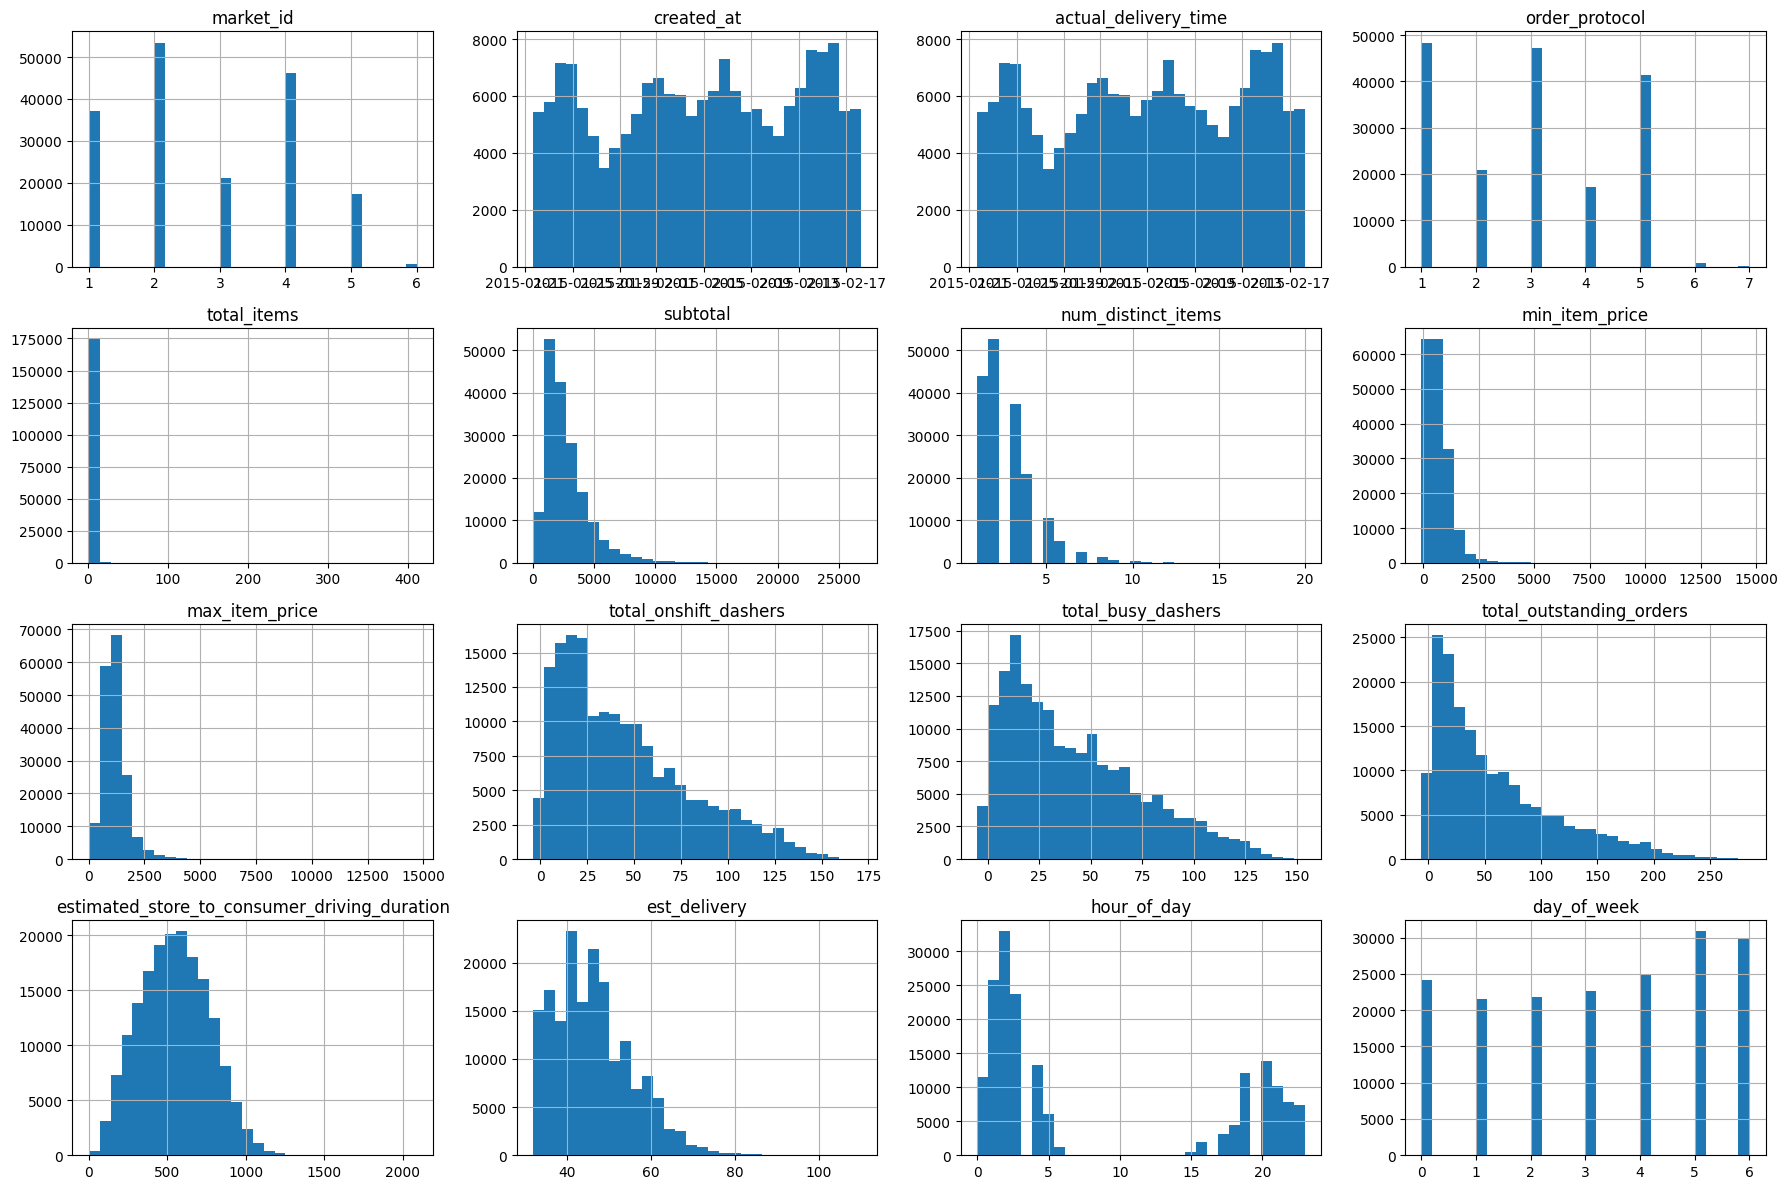

In [21]:
# Visualize Numerical Features (Histogram)

df.hist(figsize=(18, 12), bins=30)
plt.tight_layout()
plt.show()

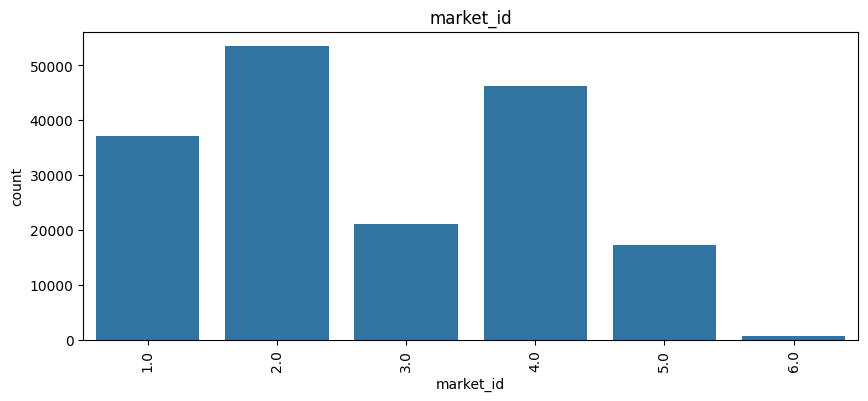

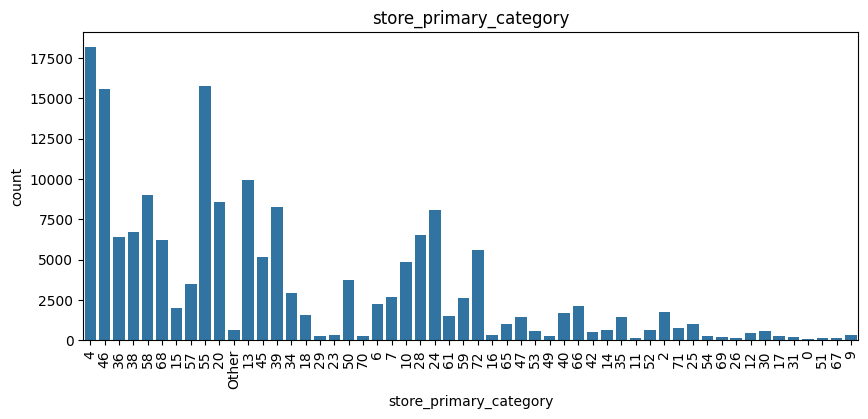

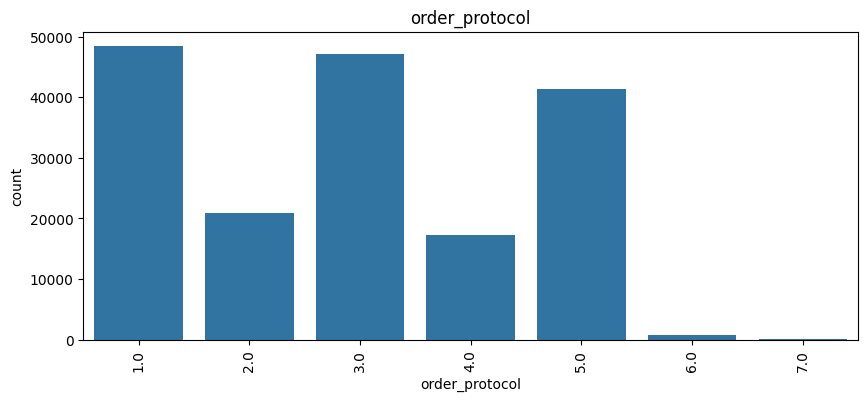

In [22]:
# Count Plots for Categorical Features

cat_cols = ['market_id', 'store_primary_category', 'order_protocol']

for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=90)
    plt.title(col)
    plt.show()

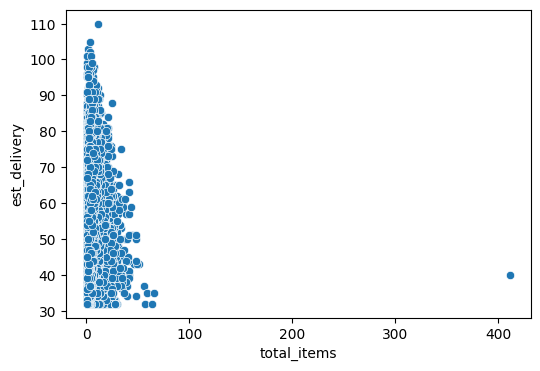

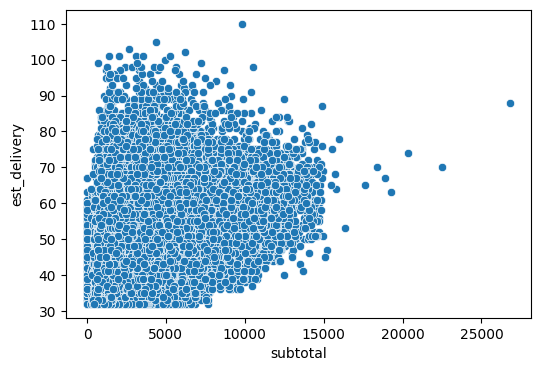

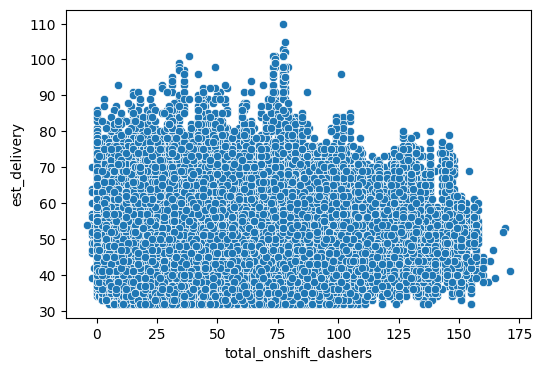

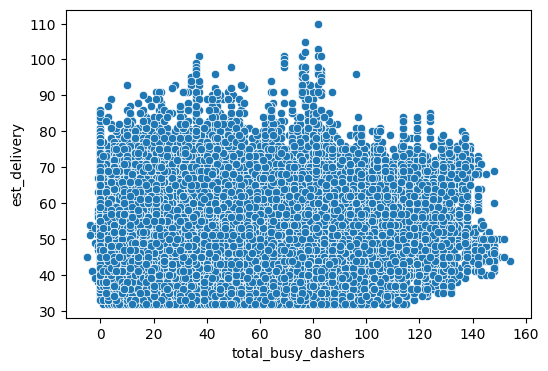

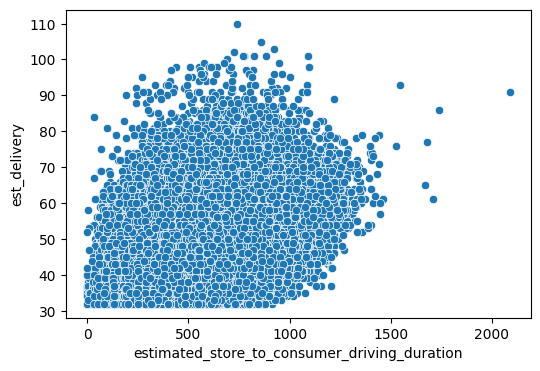

In [23]:
# Scatter Plot (Feature vs Target)

num_cols = [
    'total_items',
    'subtotal',
    'total_onshift_dashers',
    'total_busy_dashers',
    'estimated_store_to_consumer_driving_duration'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y='est_delivery')
    plt.show()

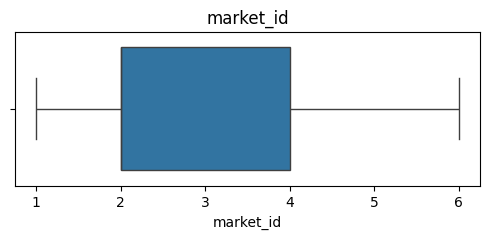

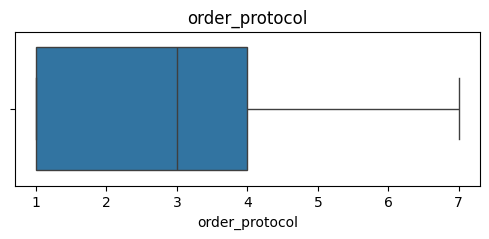

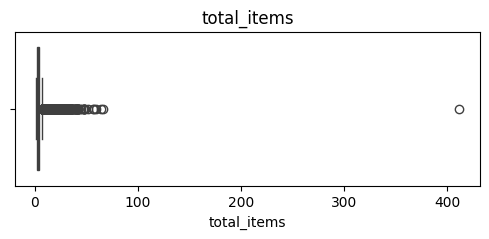

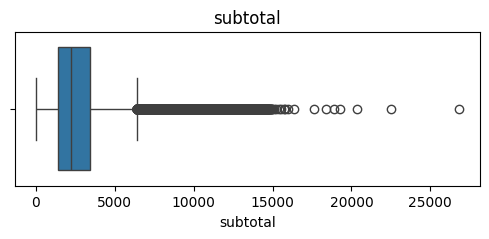

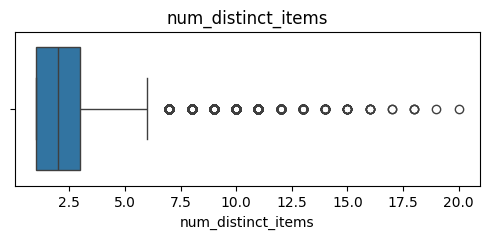

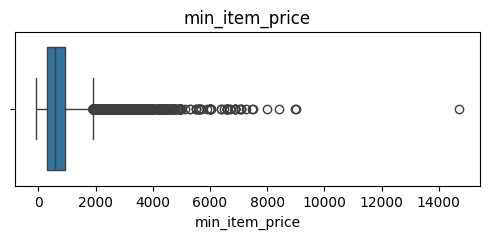

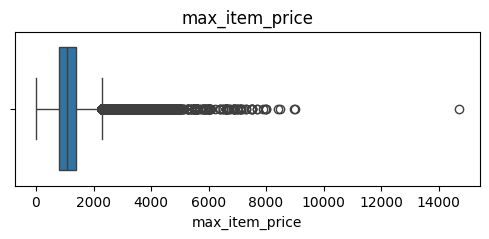

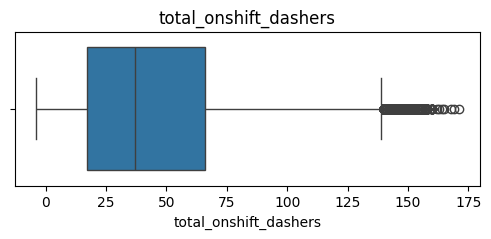

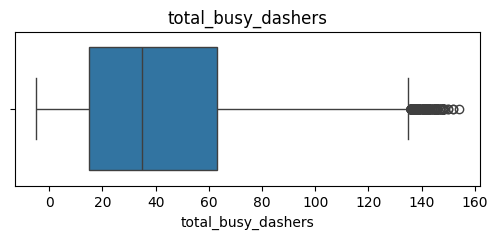

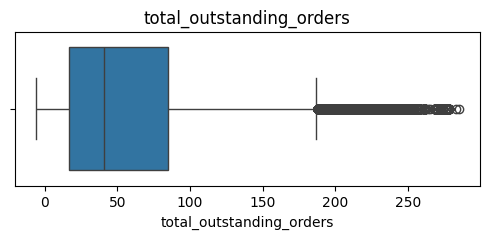

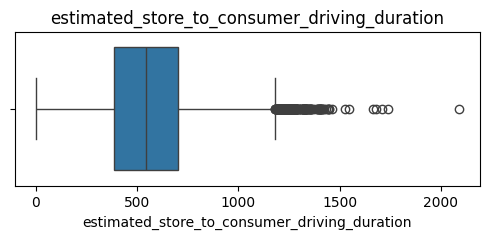

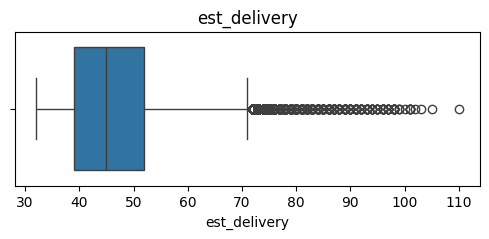

In [24]:
# checking Outliers using Boxplot

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Although several numerical features exhibit outliers, they are retained because they represent genuine business scenarios (e.g., large orders, long-distance deliveries, and peak-hour traffic) rather than data errors. Removing these observations could lead to information loss and reduce the model's ability to generalize to real-world delivery situations.

#### Encoding Categorical Features

In [25]:
categorical_cols = ['market_id','store_primary_category','order_protocol']

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [26]:
df.shape

(175777, 78)

In [27]:
df.head()

,created_at,actual_delivery_time,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,...,store_primary_category_70,store_primary_category_71,store_primary_category_72,store_primary_category_Other,order_protocol_2.0,order_protocol_3.0,order_protocol_4.0,order_protocol_5.0,order_protocol_6.0,order_protocol_7.0
0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,3441,4,557,1239,33.0,14.0,21.0,...,0,0,0,0,0,0,0,0,0,0
1,2015-02-10 21:49:25,2015-02-10 22:33:25,1,1900,1,1400,1400,1.0,2.0,2.0,...,0,0,0,0,1,0,0,0,0,0
2,2015-02-16 00:11:35,2015-02-16 01:06:35,4,4771,3,820,1604,8.0,6.0,18.0,...,0,0,0,0,0,1,0,0,0,0
3,2015-02-12 03:36:46,2015-02-12 04:35:46,1,1525,1,1525,1525,5.0,6.0,8.0,...,0,0,0,0,0,0,0,0,0,0
4,2015-01-27 02:12:36,2015-01-27 02:58:36,2,3620,2,1425,2195,5.0,5.0,7.0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
# removing the datetime features, we have already engineered useful features out of it

df.drop(columns=['created_at', 'actual_delivery_time'], inplace=True)

#### Train - Test Split

In [29]:
X = df.drop(columns=['est_delivery'])
y = df['est_delivery']

In [30]:
from sklearn.model_selection import train_test_split

# 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Split training set into Train and Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,   # 20% of 80% = 16% of total data
    random_state=42
)

In [31]:
print("Training Features :", X_train.shape)
print("Validation Features  :", X_val.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Validation Target :", y_val.shape)
print("Testing Target    :", y_test.shape)

Training Features : (112496, 75)
Validation Features  : (28125, 75)
Testing Features  : (35156, 75)
Training Target   : (112496,)
Validation Target : (28125,)
Testing Target    : (35156,)


#### Feature Scaling

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

In [33]:
X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

#### Training the Neural Networks

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Porter Neural Networks/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [35]:
# check the input shape

print(X_train_scaled.shape)

(112496, 75)


In [36]:
# building baseline Neural Network with 2 hidden layers

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Porter Neural Networks/venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [38]:
# view the model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,977 (27.25 KB)

 Trainable params: 6,977 (27.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# training the model

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 2s 356us/step - loss: 270.2728 - mae: 8.9535 - val_loss: 6.5080 - val_mae: 1.7804
Epoch 2/50
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 1s 335us/step - loss: 5.6693 - mae: 1.6843 - val_loss: 3.6175 - val_mae: 1.3793
Epoch 3/50
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 1s 335us/step - loss: 3.4190 - mae: 1.2887 - val_loss: 2.0253 - val_mae: 1.0011
Epoch 4/50
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 1s 335us/step - loss: 1.7227 - mae: 0.9289 - val_loss: 1.7783 - val_mae: 0.9929
Epoch 5/50
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 1s 337us/step - loss: 1.1133 - mae: 0.7551 - val_loss: 1.0362 - val_mae: 0.7592
Epoch 6/50
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 1s 334us/step - loss: 0.8817 - mae: 0.6626 - val_loss: 0.7656 - val_mae: 0.6427
Epoch 7/50
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 1s 335us/step - loss: 0.7352 - mae: 0.5977 - val_loss: 0.7290 - val_mae: 0.5975
Epoch 8/50
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 1s 334us/step - loss: 0.6211 - mae: 0.5562 - val_loss: 0.6372 - val_mae: 0.5475
Epoch 9/50
3516/3516 ━

In [40]:
# Evaluating the model

test_loss, test_mae = model.evaluate(
    X_test_scaled,
    y_test
)

print(test_mae)

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 233us/step - loss: 0.2699 - mae: 0.3634
0.36238130927085876


On average, the model's prediction is only 0.37 minutes (≈22 seconds) away from the true delivery time. 

In [41]:
# checking y_train distribution

y_train.describe()

count    112496.000000
mean         46.181473
std           9.309866
min          32.000000
25%          39.000000
50%          45.000000
75%          52.000000
max         110.000000
Name: est_delivery, dtype: float64

#### Trained Model Evaluation

In [42]:
# correlation with target feature

df.corr(numeric_only=True)['est_delivery'].sort_values(ascending=False)

est_delivery                                    1.000000
estimated_store_to_consumer_driving_duration    0.460173
subtotal                                        0.413267
total_outstanding_orders                        0.384999
num_distinct_items                              0.312055
                                                  ...   
store_primary_category_58                      -0.082774
order_protocol_5.0                             -0.084833
market_id_2.0                                  -0.094109
order_protocol_4.0                             -0.105159
hour_of_day                                    -0.346366
Name: est_delivery, Length: 76, dtype: float64

##### There is no single feature dominating the prediction. Initially, I suspected "estimated_store_to_consumer_driving_duration" might almost equal the target, but its correlation is only 0.46, which is moderate. That means the Neural Network is genuinely learning interactions among multiple features rather than simply copying one feature. This is a good sign.

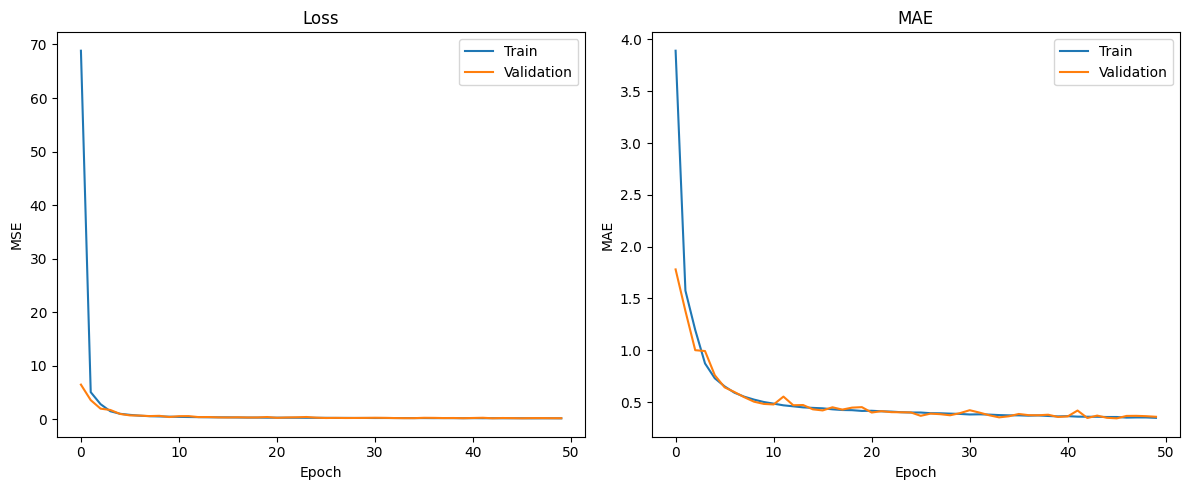

In [43]:
# now plotting the learning curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Validation')
plt.title('MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
# Evaluate with additional metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)

print(mae)
print(rmse)
print(r2)

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 177us/step
0.36238129611768904
0.49657123086249155
0.9971827871740616


- MAE = 0.37 -> Average prediction error ≈ 22 seconds.
- RMSE = 0.50 -> There are no large prediction errors. The model is performing consistently across the test set.
- R2 = 0.99 -> The model explains 99.7% of the variance in delivery time. This is an exceptionally high score

In [45]:
# Actual Vs Predicted

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pred.flatten()
})

results.head(10)

,Actual,Predicted
0,50.0,50.530605
1,69.0,67.549850
2,41.0,40.783875
3,45.0,45.441063
4,40.0,40.427483
5,36.0,25.477306
6,34.0,34.500198
7,43.0,43.174622
8,32.0,31.766426
9,46.0,45.768768


In [46]:
# Residual Analysis

results["Residual"] = (
    results["Actual"] -
    results["Predicted"]
)

In [47]:
results.head(10)

,Actual,Predicted,Residual
0,50.0,50.530605,-0.530605
1,69.0,67.549850,1.450150
2,41.0,40.783875,0.216125
3,45.0,45.441063,-0.441063
4,40.0,40.427483,-0.427483
5,36.0,25.477306,10.522694
6,34.0,34.500198,-0.500198
7,43.0,43.174622,-0.174622
8,32.0,31.766426,0.233574
9,46.0,45.768768,0.231232


#### Business Insights

Based on the baseline Neural Network model, the following business insights can be derived:

##### 1. The model predicts delivery time with high accuracy
- The model achieved an **MAE of 0.37 minutes (approximately 22 seconds)**, indicating that the predicted delivery times are very close to the actual delivery times.
- Such accurate ETA predictions can improve customer trust and satisfaction by setting realistic delivery expectations.

---

##### 2. Estimated driving duration is the strongest predictor
- Among all the features, **estimated_store_to_consumer_driving_duration** has the highest positive correlation with the target variable.
- This indicates that the travel duration between the restaurant and the customer plays a significant role in determining the overall delivery time.

---

##### 3. Operational workload impacts delivery time
- Features such as **total_busy_dashers** and **total_outstanding_orders** show a positive relationship with delivery time.
- This suggests that delivery times tend to increase during periods of high demand when more delivery partners are occupied.

---

##### 4. Order characteristics influence delivery time
- Features like **subtotal**, **total_items**, and **num_distinct_items** also contribute to the prediction.
- Larger or more complex orders generally require additional preparation time, leading to slightly longer delivery durations.

---

##### 5. Market and restaurant categories have a measurable impact
- Different markets and restaurant categories contribute differently to delivery time.
- This indicates that regional demand patterns and restaurant operations influence the overall delivery experience.

---

##### 6. The model generalizes well
- The baseline model achieved an **R² score of 0.997**, explaining approximately **99.7% of the variation** in delivery time.
- The low MAE and RMSE values suggest that the model performs consistently on unseen data without significant prediction errors.

---

#### Business Recommendations

##### Recommendation 1: Provide more accurate ETAs to customers
- Deploy the model to estimate delivery times in real time.
- More accurate ETAs can improve customer satisfaction and reduce support inquiries related to delayed deliveries.

---

##### Recommendation 2: Improve delivery partner allocation during peak hours
- Since delivery partner workload affects delivery time, Porter can proactively increase the availability of delivery partners during high-demand periods.
- This can help reduce delivery delays and improve operational efficiency.

---

##### Recommendation 3: Optimize restaurant preparation for large orders
- Restaurants receiving larger or more complex orders can be notified in advance to prioritize preparation.
- This can reduce overall delivery time for high-value orders.

---

##### Recommendation 4: Continuously monitor ETA accuracy
- The model should be retrained periodically using the latest operational data.
- This will help maintain prediction accuracy as customer demand, traffic conditions, and delivery patterns change over time.

---

#### Conclusion

The baseline Neural Network model demonstrates excellent predictive performance with very low prediction error and a high R² score. The results indicate that operational factors, driving duration, and order characteristics are the primary drivers of delivery time. By leveraging these predictions, Porter can provide more accurate ETAs, optimize delivery operations, improve customer satisfaction, and make data-driven business decisions.

#### Saving the Artifacts

In [48]:
import os
import pickle
import json

In [49]:
#checking if artifacts folder is present

os.makedirs("artifacts", exist_ok=True)

In [50]:
#saving the trained model

model.save("artifacts/model.keras")

In [51]:
#saving Scaler

with open("artifacts/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [52]:
#saving the feature columns

feature_columns = X.columns.tolist()

with open("artifacts/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

In [53]:
#saving the model metadata

metadata = {
    "model_type": "Neural Network",
    "target": "est_delivery",
    "target_unit": "minutes",
    "input_features": len(feature_columns),
    "architecture": [64, 32, 1],
    "loss": "mse",
    "optimizer": "adam",
    "metrics": ["mae"],
    "test_mae": float(mae),
    "test_rmse": float(rmse),
    "test_r2": float(r2)
}


with open("artifacts/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [54]:
os.listdir("artifacts")

['scaler.pkl', 'model_metadata.json', 'feature_columns.pkl', 'model.keras']

In [56]:
#saving the raw features

raw_feature_columns = [
    "market_id",
    "created_at",
    "store_primary_category",
    "order_protocol",
    "total_items",
    "subtotal",
    "num_distinct_items",
    "min_item_price",
    "max_item_price",
    "total_onshift_dashers",
    "total_busy_dashers",
    "total_outstanding_orders",
    "estimated_store_to_consumer_driving_duration"
]

with open("artifacts/raw_feature_columns.pkl", "wb") as f:
    pickle.dump(raw_feature_columns, f)

print("Saved raw feature columns successfully.")

Saved raw feature columns successfully.


In [60]:
#verify scaler

with open("artifacts/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print(type(scaler))
print("Scaler features:", scaler.n_features_in_)

<class 'sklearn.preprocessing._data.StandardScaler'>
Scaler features: 75


In [61]:
#verify model inputs

from tensorflow.keras.models import load_model

model = load_model("artifacts/model.keras")

print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

Model input shape: (None, 75)
Model output shape: (None, 1)


In [62]:
#verify feature count

with open("artifacts/feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

print("Model features:", len(feature_columns))

Model features: 75
